In [7]:
#scrapping- politifact for fake and real news .

In [8]:
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import requests
import urllib.request
import time

In [9]:
#lists to store scraped data
authors=[]
dates=[]
statements=[]
sources=[]
targets=[]

In [10]:
def scrape_website(page_number):
    page_num = str(page_number)
    url = 'https://www.politifact.com/factchecks/list/?page=' + page_num
    webpage = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(webpage.text, 'html.parser')


    statement_footer = soup.find_all('footer', class_='m-statement__footer')
    statement_quote = soup.find_all('div', class_='m-statement__quote')
    statement_meta = soup.find_all('div', class_='m-statement__meta')
    target = soup.find_all('div', class_='m-statement__meter')


    # Author + Date
    for i in statement_footer:
        text = i.text.strip().split()

        # defensive check
        if len(text) >= 7:
            full_name = text[1] + ' ' + text[2]
            date = text[4] + ' ' + text[5] + ' ' + text[6]

            authors.append(full_name)
            dates.append(date)


    # Statement

    for i in statement_quote:
        a_tag = i.find('a')
        if a_tag:
            statements.append(a_tag.text.strip())


    # Source

    for i in statement_meta:
        a_tag = i.find('a')
        if a_tag:
            sources.append(a_tag.text.strip())


    # Verdict / Target

    for i in target:
        img = i.find('img')
        if img and img.get('alt'):
            targets.append(img.get('alt').strip())


In [54]:
def scrape_website(page_number, start_date=None, end_date=None):
    page_num = str(page_number)
    url = 'https://www.politifact.com/factchecks/list/?page=' + page_num
    webpage = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(webpage.text, 'html.parser')

    statement_footer = soup.find_all('footer', class_='m-statement__footer')
    statement_quote = soup.find_all('div', class_='m-statement__quote')
    statement_meta = soup.find_all('div', class_='m-statement__meta')
    target = soup.find_all('div', class_='m-statement__meter')

    page_dates = []

    # Keep rows aligned by iterating across the page entries together
    for footer, quote, meta, meter in zip(statement_footer, statement_quote, statement_meta, target):
        text = footer.text.strip().split()

        # defensive check
        if len(text) >= 7:
            full_name = text[1] + ' ' + text[2]
            date_text = text[4] + ' ' + text[5] + ' ' + text[6]
            date_value = pd.to_datetime(date_text, errors='coerce')
            page_dates.append(date_value)

            if pd.notna(date_value):
                within_range = True
                if start_date is not None and date_value < start_date:
                    within_range = False
                if end_date is not None and date_value > end_date:
                    within_range = False

                if within_range:
                    authors.append(full_name)
                    dates.append(date_text)

                    a_tag = quote.find('a')
                    if a_tag:
                        statements.append(a_tag.text.strip())
                    else:
                        statements.append('')

                    a_tag = meta.find('a')
                    if a_tag:
                        sources.append(a_tag.text.strip())
                    else:
                        sources.append('')

                    img = meter.find('img')
                    if img and img.get('alt'):
                        targets.append(img.get('alt').strip())
                    else:
                        targets.append('')

    # Return True when this page is already older than the requested range
    valid_dates = [d for d in page_dates if pd.notna(d)]
    if start_date is not None and valid_dates and min(valid_dates) < start_date:
        return True

    return False

In [60]:
#Here what date range you want to scrape for. You can change it as per your requirement. By default, it is set to scrape from May 1, 2023 to May 11, 2026.


from datetime import datetime

# Set the date range you want to scrape
start_date_str = '2023-05-01'  # inclusive
end_date_str = '2026-05-11'    # inclusive

start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# Clear old data if you want a fresh scrape for the selected range
authors.clear()
dates.clear()
statements.clear()
sources.clear()
targets.clear()

print(f"Scraping Politifact data from {start_date.date()} to {end_date.date()}")

Scraping Politifact data from 2023-05-01 to 2026-05-11


In [61]:
# loop through webpages and scrape only the selected date range
n = 100
for i in range(1, n):
    stop_scraping = scrape_website(i, start_date=start_date, end_date=end_date)
    if stop_scraping:
        print(f"Stopping at page {i} because older records are outside the selected date range.")
        break


In [62]:

#creating the dataframe
min_len=min(len(authors),len(dates),len(statements),len(sources),len(targets))
data=pd.DataFrame({
'authors':authors[:min_len],
'dates':dates[:min_len],
'statements':statements[:min_len],
'sources':sources[:min_len],
'targets':targets[:min_len]
})
data

,authors,dates,statements,sources,targets
0,Louis Jacobson,"May 8, 2026",Gasoline prices have “come down very substanti...,Donald Trump,false
1,Samantha Putterman,"May 8, 2026",Congress passed the 1965 Voting Rights Act bec...,Byron Donalds,false
2,Maria Briceño,"May 8, 2026",Republicans “want you to pay $1 Billion for a ...,Marcy Kaptur,mostly-true
3,Conor Amendola,"May 7, 2026",Proposed data centers in New York state would ...,Liz Krueger,barely-true
4,Louis Jacobson,"May 7, 2026",“California only has ‘enough’ oil and gas supp...,X posts,false
...,...,...,...,...,...
2652,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false
2653,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false
2654,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire
2655,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire


In [63]:
data.tail()

,authors,dates,statements,sources,targets
2652,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false
2653,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false
2654,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire
2655,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire
2656,Ciara O'Rourke,"August 24, 2023",U.S. Navy SEALs rescued 807 children who were ...,Instagram posts,false


In [64]:
#function to get binary number from the target
def BinaryTarget(targets):
  if targets=='true' or targets=='mostly-true' or targets=='half-true':
    return 1
  else:
    return 0

In [65]:
data

,authors,dates,statements,sources,targets
0,Louis Jacobson,"May 8, 2026",Gasoline prices have “come down very substanti...,Donald Trump,false
1,Samantha Putterman,"May 8, 2026",Congress passed the 1965 Voting Rights Act bec...,Byron Donalds,false
2,Maria Briceño,"May 8, 2026",Republicans “want you to pay $1 Billion for a ...,Marcy Kaptur,mostly-true
3,Conor Amendola,"May 7, 2026",Proposed data centers in New York state would ...,Liz Krueger,barely-true
4,Louis Jacobson,"May 7, 2026",“California only has ‘enough’ oil and gas supp...,X posts,false
...,...,...,...,...,...
2652,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false
2653,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false
2654,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire
2655,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire


In [66]:
#function to get a binary label true(real) pr false(fake) from the target
def FinalTarget(targets):
  if targets=="true" or targets=="mostly-true" or targets=="half-true":
    return 'Real'
  else:
    return "Fake"


In [67]:
data['FinalTarget']=data['targets'].apply(FinalTarget)
data['BinaryTarget']=data['targets'].apply(BinaryTarget)

In [68]:
data

,authors,dates,statements,sources,targets,FinalTarget,BinaryTarget
0,Louis Jacobson,"May 8, 2026",Gasoline prices have “come down very substanti...,Donald Trump,false,Fake,0
1,Samantha Putterman,"May 8, 2026",Congress passed the 1965 Voting Rights Act bec...,Byron Donalds,false,Fake,0
2,Maria Briceño,"May 8, 2026",Republicans “want you to pay $1 Billion for a ...,Marcy Kaptur,mostly-true,Real,1
3,Conor Amendola,"May 7, 2026",Proposed data centers in New York state would ...,Liz Krueger,barely-true,Fake,0
4,Louis Jacobson,"May 7, 2026",“California only has ‘enough’ oil and gas supp...,X posts,false,Fake,0
...,...,...,...,...,...,...,...
2652,Maria Briceño,"August 25, 2023","El incendio forestal en Maui, Hawai, fue provo...",TikTok posts,false,Fake,0
2653,Ciara O'Rourke,"August 24, 2023",Former President Barack Obama “reacts to chef’...,Facebook posts,false,Fake,0
2654,Ciara O'Rourke,"August 24, 2023",“Military arrests FEMA Deputy Administrator Er...,Facebook posts,pants-fire,Fake,0
2655,Jeff Cercone,"August 24, 2023",“The reality is more people are dying of bad c...,Vivek Ramaswamy,pants-fire,Fake,0


In [69]:

data.to_csv('politifact_data_final.csv', index=False)

#Applying all major supervised ML models 

NLP FEATURE EXTRACTION

1. TF-IDF Vectorization...
   TF-IDF shape: (2125, 5000)
2. Count Vectorization...
   Count Vector shape: (2125, 5000)

CLASS IMBALANCE ANALYSIS

BEFORE SMOTE:
Training data distribution: Counter({np.int64(0): 1892, np.int64(1): 233})
Class distribution ratio: 233 : 1892

Applying SMOTE to training data...
AFTER SMOTE:
Training data distribution: Counter({np.int64(0): 1892, np.int64(1): 1892})
Class distribution ratio: 1892 : 1892
Original training samples: 2125
SMOTE-augmented training samples: 3784


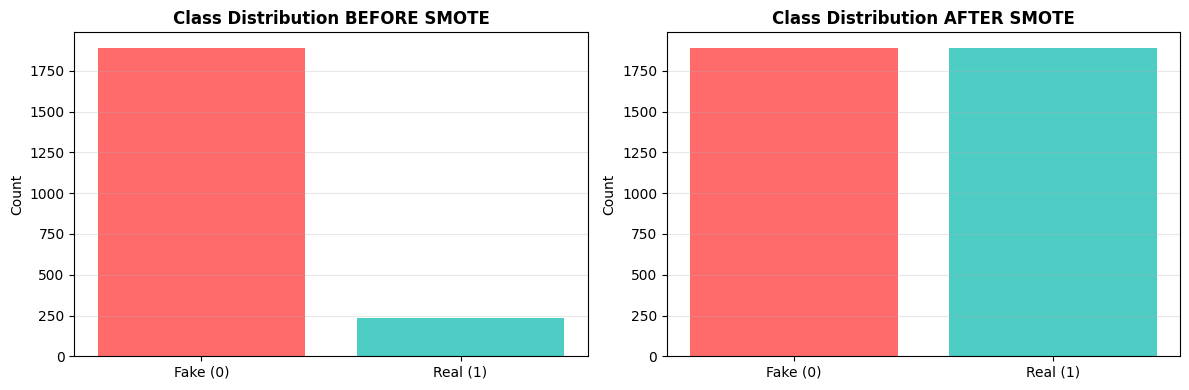


TRAINING SUPERVISED ML MODELS

1. Logistic Regression (TF-IDF + SMOTE)...
2. Multinomial Naive Bayes (Count Vector + SMOTE)...
3. Random Forest (TF-IDF + SMOTE)...
4. Support Vector Machine (TF-IDF + SMOTE)...
5. Gradient Boosting (TF-IDF + SMOTE)...

MODEL COMPARISON RESULTS

Logistic Regression:
  Accuracy:  0.8759
  Precision: 0.4490
  Recall:    0.3607
  F1-Score:  0.4000

Naive Bayes:
  Accuracy:  0.8365
  Precision: 0.3646
  Recall:    0.5738
  F1-Score:  0.4459

Random Forest:
  Accuracy:  0.8816
  Precision: 0.4444
  Recall:    0.1311
  F1-Score:  0.2025

SVM:
  Accuracy:  0.8797
  Precision: 0.4634
  Recall:    0.3115
  F1-Score:  0.3725

Gradient Boosting:
  Accuracy:  0.8853
  Precision: 0.5000
  Recall:    0.3934
  F1-Score:  0.4404

COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8759     0.4490  0.3607    0.4000
        Naive Bayes    0.8365     0.3646  0.5738    0.4459
      Random Forest    0.8816     0.4444  0.1311 

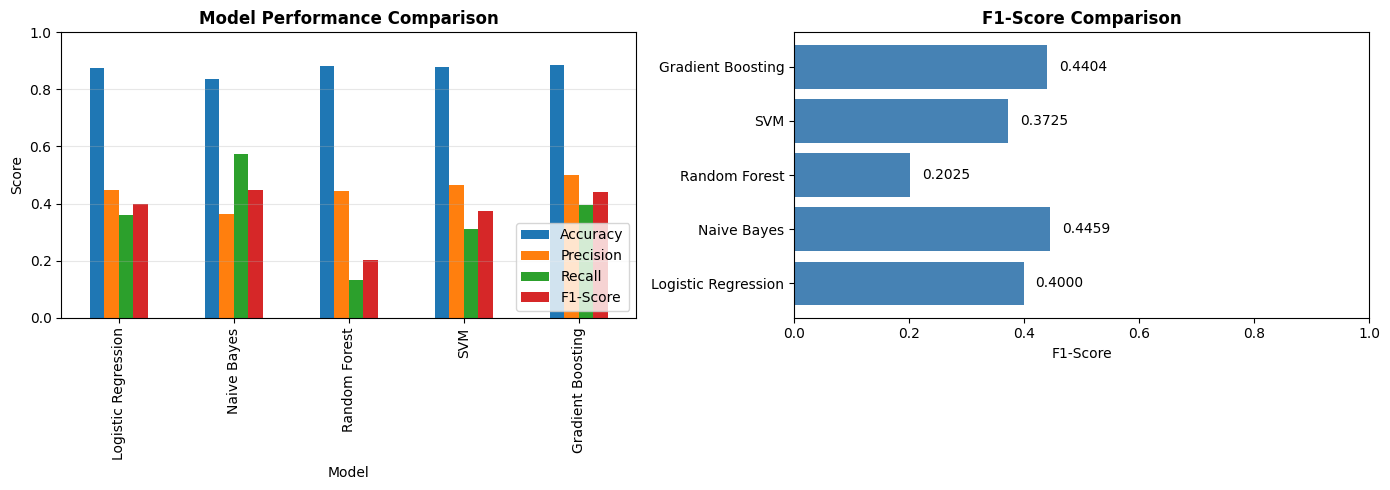


✅ ML Pipeline Complete!


In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load data if not already in memory
if 'data' not in locals():
    try:
        data = pd.read_csv('politifact_data_final.csv')
        print("Data loaded from CSV file")
    except:
        print("CSV not found. Please run the earlier cells to generate data.")

# Ensure BinaryTarget exists
if 'BinaryTarget' not in data.columns:
    def BinaryTarget(targets):
        if targets=='true' or targets=='mostly-true' or targets=='half-true':
            return 1
        else:
            return 0
    data['BinaryTarget'] = data['targets'].apply(BinaryTarget)
    print("BinaryTarget column created")

# ============= NLP FEATURE EXTRACTION =============
print("="*60)
print("NLP FEATURE EXTRACTION")
print("="*60)

X_text = data['statements'].values
y_labels = data['BinaryTarget'].values

X_train_text, X_test_text, y_train_ml, y_test_ml = train_test_split(X_text, y_labels, test_size=0.2, random_state=42)

# TF-IDF Vectorization
print("\n1. TF-IDF Vectorization...")
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf = tfidf_vec.transform(X_test_text)
print(f"   TF-IDF shape: {X_train_tfidf.shape}")

# Count Vectorization
print("2. Count Vectorization...")
count_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_count = count_vec.fit_transform(X_train_text)
X_test_count = count_vec.transform(X_test_text)
print(f"   Count Vector shape: {X_train_count.shape}")

# ============= SMOTE BALANCING BEFORE TRAINING =============
print("\n" + "="*60)
print("CLASS IMBALANCE ANALYSIS")
print("="*60)
print("\nBEFORE SMOTE:")
print(f"Training data distribution: {Counter(y_train_ml)}")
print(f"Class distribution ratio: {Counter(y_train_ml)[1]} : {Counter(y_train_ml)[0]}")

print("\nApplying SMOTE to training data...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_tfidf_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train_ml)
X_train_count_smote, _ = smote.fit_resample(X_train_count, y_train_ml)

print("AFTER SMOTE:")
print(f"Training data distribution: {Counter(y_train_smote)}")
print(f"Class distribution ratio: {Counter(y_train_smote)[1]} : {Counter(y_train_smote)[0]}")
print(f"Original training samples: {X_train_tfidf.shape[0]}")
print(f"SMOTE-augmented training samples: {X_train_tfidf_smote.shape[0]}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Fake (0)', 'Real (1)'], list(Counter(y_train_ml).values()), color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Class Distribution BEFORE SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(['Fake (0)', 'Real (1)'], list(Counter(y_train_smote).values()), color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Class Distribution AFTER SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============= TRAINING SUPERVISED ML MODELS =============
print("\n" + "="*60)
print("TRAINING SUPERVISED ML MODELS")
print("="*60)

smote_models = {}

print("\n1. Logistic Regression (TF-IDF + SMOTE)...")
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_tfidf_smote, y_train_smote)
lr_smote_pred = lr_smote.predict(X_test_tfidf)
smote_models['Logistic Regression'] = lr_smote_pred

print("2. Multinomial Naive Bayes (Count Vector + SMOTE)...")
nb_smote = MultinomialNB()
nb_smote.fit(X_train_count_smote, y_train_smote)
nb_smote_pred = nb_smote.predict(X_test_count)
smote_models['Naive Bayes'] = nb_smote_pred

print("3. Random Forest (TF-IDF + SMOTE)...")
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_tfidf_smote, y_train_smote)
rf_smote_pred = rf_smote.predict(X_test_tfidf)
smote_models['Random Forest'] = rf_smote_pred

print("4. Support Vector Machine (TF-IDF + SMOTE)...")
svm_smote = SVC(kernel='linear', random_state=42)
svm_smote.fit(X_train_tfidf_smote, y_train_smote)
svm_smote_pred = svm_smote.predict(X_test_tfidf)
smote_models['SVM'] = svm_smote_pred

print("5. Gradient Boosting (TF-IDF + SMOTE)...")
gb_smote = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_smote.fit(X_train_tfidf_smote, y_train_smote)
gb_smote_pred = gb_smote.predict(X_test_tfidf)
smote_models['Gradient Boosting'] = gb_smote_pred

# ============= MODEL COMPARISON & EVALUATION =============
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)

comparison_data = []
for model_name, predictions in smote_models.items():
    accuracy = accuracy_score(y_test_ml, predictions)
    precision = precision_score(y_test_ml, predictions, average='binary')
    recall = recall_score(y_test_ml, predictions, average='binary')
    f1 = f1_score(y_test_ml, predictions, average='binary')

    comparison_data.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("COMPARISON TABLE")
print("="*60)
print(comparison_df.to_string(index=False))

best_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.loc[best_idx]
print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model['Model']}")
print(f"   F1-Score: {best_model['F1-Score']}, Accuracy: {best_model['Accuracy']}")
print(f"{'='*60}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
models_list = comparison_df['Model'].tolist()
f1_scores = comparison_df['F1-Score'].tolist()
axes[1].barh(models_list, f1_scores, color='steelblue')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlim([0, 1])
for i, v in enumerate(f1_scores):
    axes[1].text(v + 0.02, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

print("\n✅ ML Pipeline Complete!")


BEFORE vs AFTER SMOTE COMPARISON
              Model  Accuracy (Before)  Accuracy (After)  F1-Score (Before)  F1-Score (After)  F1 Improvement %
Logistic Regression             0.8853            0.8759             0.0000            0.4000              0.00
        Naive Bayes             0.8910            0.8365             0.3958            0.4459             12.64
      Random Forest             0.8872            0.8816             0.1429            0.2025             41.77
                SVM             0.8910            0.8797             0.2162            0.3725             72.30
  Gradient Boosting             0.8853            0.8853             0.1644            0.4404            167.89


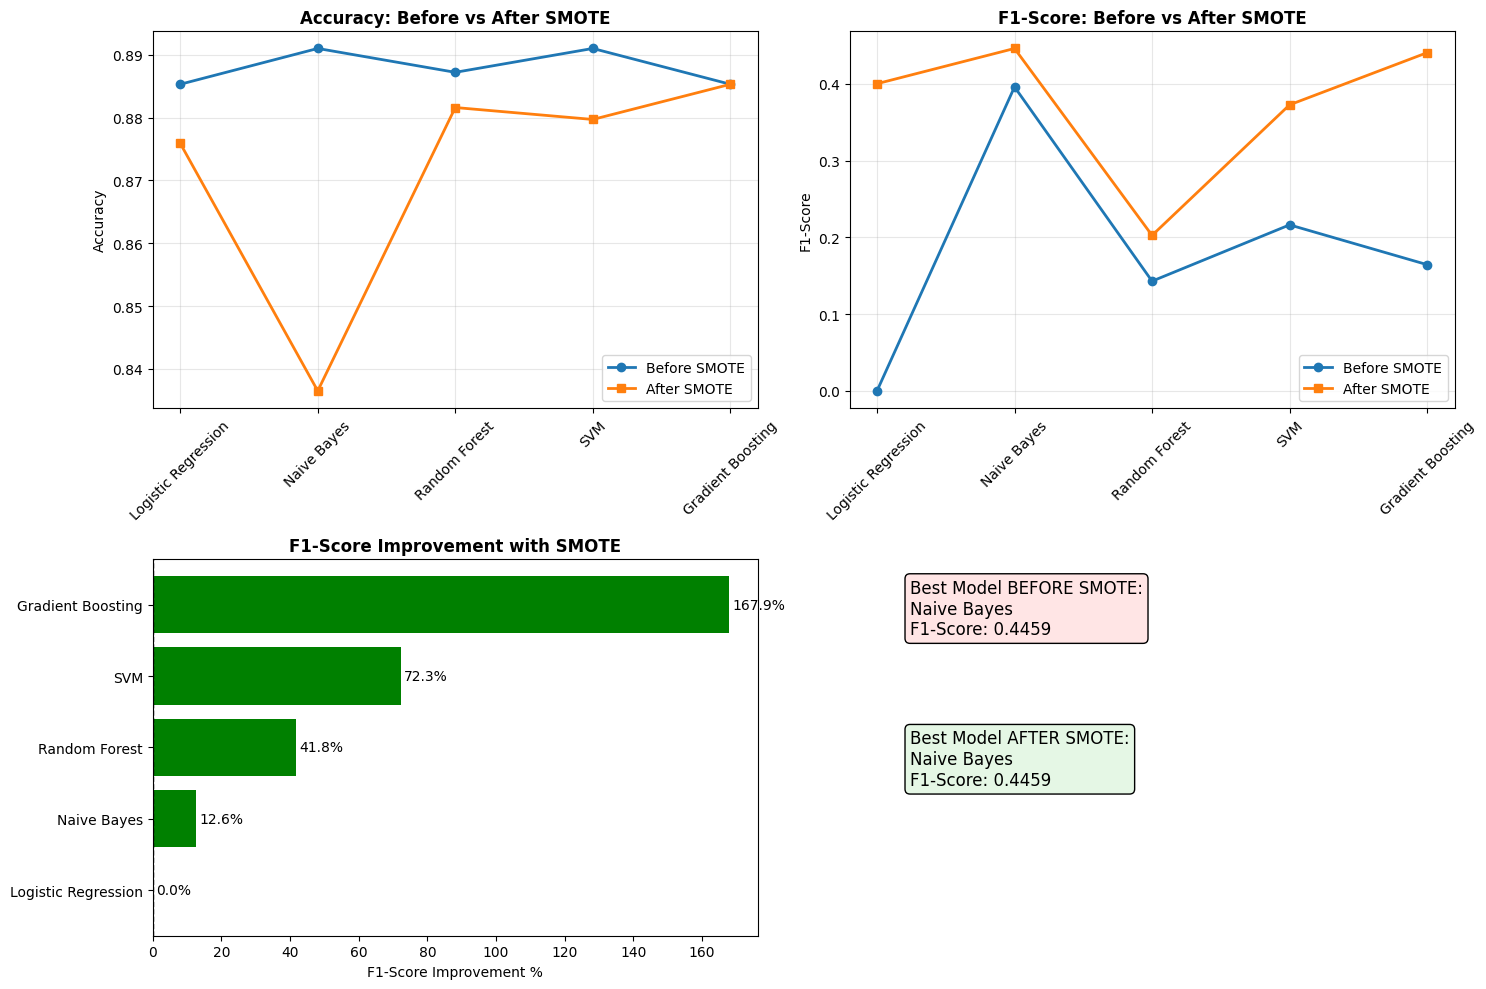


✅ SMOTE Analysis Complete!


In [77]:
print("\n" + "="*60)
print("BEFORE vs AFTER SMOTE COMPARISON")
print("="*60)

# Store results for comparison
comparison_before_after = []

for model_name in models.keys():
    # Original model predictions
    orig_pred = models[model_name]
    orig_acc = accuracy_score(y_test_ml, orig_pred)
    orig_prec = precision_score(y_test_ml, orig_pred, average='binary')
    orig_rec = recall_score(y_test_ml, orig_pred, average='binary')
    orig_f1 = f1_score(y_test_ml, orig_pred, average='binary')
    
    # SMOTE model predictions
    smote_pred = smote_models[model_name]
    smote_acc = accuracy_score(y_test_ml, smote_pred)
    smote_prec = precision_score(y_test_ml, smote_pred, average='binary')
    smote_rec = recall_score(y_test_ml, smote_pred, average='binary')
    smote_f1 = f1_score(y_test_ml, smote_pred, average='binary')
    
    # Calculate improvements
    acc_imp = ((smote_acc - orig_acc) / orig_acc * 100) if orig_acc != 0 else 0
    f1_imp = ((smote_f1 - orig_f1) / orig_f1 * 100) if orig_f1 != 0 else 0
    
    comparison_before_after.append({
        'Model': model_name,
        'Accuracy (Before)': round(orig_acc, 4),
        'Accuracy (After)': round(smote_acc, 4),
        'F1-Score (Before)': round(orig_f1, 4),
        'F1-Score (After)': round(smote_f1, 4),
        'F1 Improvement %': round(f1_imp, 2)
    })

comparison_smote_df = pd.DataFrame(comparison_before_after)
print(comparison_smote_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
models_list = comparison_smote_df['Model'].tolist()
axes[0, 0].plot(models_list, comparison_smote_df['Accuracy (Before)'], marker='o', label='Before SMOTE', linewidth=2)
axes[0, 0].plot(models_list, comparison_smote_df['Accuracy (After)'], marker='s', label='After SMOTE', linewidth=2)
axes[0, 0].set_title('Accuracy: Before vs After SMOTE', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# F1-Score comparison
axes[0, 1].plot(models_list, comparison_smote_df['F1-Score (Before)'], marker='o', label='Before SMOTE', linewidth=2)
axes[0, 1].plot(models_list, comparison_smote_df['F1-Score (After)'], marker='s', label='After SMOTE', linewidth=2)
axes[0, 1].set_title('F1-Score: Before vs After SMOTE', fontweight='bold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# F1 Improvement percentage
colors = ['green' if x > 0 else 'red' for x in comparison_smote_df['F1 Improvement %']]
axes[1, 0].barh(models_list, comparison_smote_df['F1 Improvement %'], color=colors)
axes[1, 0].set_xlabel('F1-Score Improvement %')
axes[1, 0].set_title('F1-Score Improvement with SMOTE', fontweight='bold')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(comparison_smote_df['F1 Improvement %']):
    axes[1, 0].text(v + 1, i, f'{v:.1f}%', va='center')

# Best models after SMOTE
best_after = comparison_smote_df.loc[comparison_smote_df['F1-Score (After)'].idxmax()]
best_before = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.8, f"Best Model BEFORE SMOTE:\n{best_before['Model']}\nF1-Score: {best_before['F1-Score']}", 
                fontsize=12, bbox=dict(boxstyle='round', facecolor='#FFE5E5'))
axes[1, 1].text(0.1, 0.4, f"Best Model AFTER SMOTE:\n{best_after['Model']}\nF1-Score: {best_after['F1-Score (After)']}", 
                fontsize=12, bbox=dict(boxstyle='round', facecolor='#E5F7E5'))

plt.tight_layout()
plt.show()

print("\n✅ SMOTE Analysis Complete!")

# Deep Learning Models: ANN and RNN

In [79]:
print("\n" + "="*60)
print("BUILDING AND TRAINING RECURRENT NEURAL NETWORK (RNN/LSTM)")
print("="*60)

# For RNN, reshape data to 3D (samples, timesteps, features)
n_features = X_train_scaled.shape[1]
timesteps = 20  # Reduced further
feature_dim = n_features // timesteps if n_features % timesteps == 0 else n_features // timesteps + 1

# Pad data if needed
if n_features < timesteps * feature_dim:
    X_train_padded = np.pad(X_train_scaled, ((0, 0), (0, timesteps * feature_dim - n_features)), mode='constant')
    X_test_padded = np.pad(X_test_scaled, ((0, 0), (0, timesteps * feature_dim - n_features)), mode='constant')
else:
    X_train_padded = X_train_scaled
    X_test_padded = X_test_scaled

X_train_reshaped = X_train_padded.reshape((X_train_padded.shape[0], timesteps, feature_dim))
X_test_reshaped = X_test_padded.reshape((X_test_padded.shape[0], timesteps, feature_dim))

print(f"Reshaped training data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Lightweight RNN/LSTM Model
rnn_model = Sequential([
    LSTM(32, activation='relu', input_shape=(timesteps, feature_dim)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

print("\nRNN/LSTM Model Architecture:")
rnn_model.summary()

print("\nTraining RNN/LSTM...")
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history_rnn = rnn_model.fit(X_train_reshaped, y_train_smote, 
                             epochs=20, 
                             batch_size=32, 
                             validation_split=0.2,
                             callbacks=[early_stop],
                             verbose=0)

print("✅ RNN/LSTM training completed!")

# Evaluate RNN
rnn_train_loss, rnn_train_acc = rnn_model.evaluate(X_train_reshaped, y_train_smote, verbose=0)
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test_reshaped, y_test_ml, verbose=0)
rnn_pred = (rnn_model.predict(X_test_reshaped, verbose=0) > 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test_ml, rnn_pred)
rnn_precision = precision_score(y_test_ml, rnn_pred, average='binary')
rnn_recall = recall_score(y_test_ml, rnn_pred, average='binary')
rnn_f1 = f1_score(y_test_ml, rnn_pred, average='binary')

print(f"\nRNN/LSTM Performance:")
print(f"  Test Accuracy:  {rnn_accuracy:.4f}")
print(f"  Precision:      {rnn_precision:.4f}")
print(f"  Recall:         {rnn_recall:.4f}")
print(f"  F1-Score:       {rnn_f1:.4f}")


BUILDING AND TRAINING RECURRENT NEURAL NETWORK (RNN/LSTM)
Reshaped training data: (3784, 20, 250)
Reshaped test data: (532, 20, 250)

RNN/LSTM Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │        36,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,769 (143.63 KB)

 Trainable params: 36,769 (143.63 KB)

 Non-trainable params: 0 (0.00 B)


Training RNN/LSTM...
✅ RNN/LSTM training completed!

RNN/LSTM Performance:
  Test Accuracy:  0.8496
  Precision:      0.2979
  Recall:         0.2295
  F1-Score:       0.2593


In [50]:
print("\n" + "="*60)
print("BUILDING AND TRAINING ARTIFICIAL NEURAL NETWORK (ANN)")
print("="*60)

# ANN Model
ann_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dropout(0.1),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(optimizer=Adam(learning_rate=0.001), 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

print("\nANN Model Architecture:")
ann_model.summary()

print("\nTraining ANN...")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_ann = ann_model.fit(X_train_scaled, y_train_smote, 
                             epochs=50, 
                             batch_size=32, 
                             validation_split=0.2,
                             callbacks=[early_stop],
                             verbose=0)

print("✅ ANN training completed!")

# Evaluate ANN
ann_train_loss, ann_train_acc = ann_model.evaluate(X_train_scaled, y_train_smote, verbose=0)
ann_test_loss, ann_test_acc = ann_model.evaluate(X_test_scaled, y_test_ml, verbose=0)
ann_pred = (ann_model.predict(X_test_scaled) > 0.5).astype(int).flatten()

ann_accuracy = accuracy_score(y_test_ml, ann_pred)
ann_precision = precision_score(y_test_ml, ann_pred, average='binary')
ann_recall = recall_score(y_test_ml, ann_pred, average='binary')
ann_f1 = f1_score(y_test_ml, ann_pred, average='binary')

print(f"\nANN Performance:")
print(f"  Test Accuracy:  {ann_accuracy:.4f}")
print(f"  Precision:      {ann_precision:.4f}")
print(f"  Recall:         {ann_recall:.4f}")
print(f"  F1-Score:       {ann_f1:.4f}")


BUILDING AND TRAINING ARTIFICIAL NEURAL NETWORK (ANN)

ANN Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,738,689 (10.45 MB)

 Trainable params: 2,736,897 (10.44 MB)

 Non-trainable params: 1,792 (7.00 KB)


Training ANN...
✅ ANN training completed!
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

ANN Performance:
  Test Accuracy:  0.8266
  Precision:      0.2936
  Recall:         0.5517
  F1-Score:       0.3832


## Building and Training a CNN Model

In [80]:
print("\n" + "="*60)
print("BUILDING AND TRAINING ARTIFICIAL NEURAL NETWORK (ANN)")
print("="*60)

# ANN Model
ann_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nANN Model Architecture:")
ann_model.summary()

print("\nTraining ANN...")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_ann = ann_model.fit(X_train_scaled, y_train_smote,
                            epochs=50,
                            batch_size=32,
                            validation_split=0.2,
                            callbacks=[early_stop],
                            verbose=0)

print("✅ ANN training completed!")

# Evaluate ANN
ann_train_loss, ann_train_acc = ann_model.evaluate(X_train_scaled, y_train_smote, verbose=0)
ann_test_loss, ann_test_acc = ann_model.evaluate(X_test_scaled, y_test_ml, verbose=0)
ann_pred = (ann_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

ann_accuracy = accuracy_score(y_test_ml, ann_pred)
ann_precision = precision_score(y_test_ml, ann_pred, average='binary')
ann_recall = recall_score(y_test_ml, ann_pred, average='binary')
ann_f1 = f1_score(y_test_ml, ann_pred, average='binary')

print(f"\nANN Performance:")
print(f"  Test Accuracy:  {ann_accuracy:.4f}")
print(f"  Precision:      {ann_precision:.4f}")
print(f"  Recall:         {ann_recall:.4f}")
print(f"  F1-Score:       {ann_f1:.4f}")


BUILDING AND TRAINING ARTIFICIAL NEURAL NETWORK (ANN)

ANN Model Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,738,689 (10.45 MB)

 Trainable params: 2,736,897 (10.44 MB)

 Non-trainable params: 1,792 (7.00 KB)


Training ANN...
✅ ANN training completed!

ANN Performance:
  Test Accuracy:  0.8459
  Precision:      0.3333
  Recall:         0.3443
  F1-Score:       0.3387


## Building and Training an RNN Model

In [83]:
print("\n" + "="*60)
print("BUILDING AND TRAINING RECURRENT NEURAL NETWORK (RNN/LSTM)")
print("="*60)

# For RNN, reshape standardized data into 3D
n_features = X_train_scaled.shape[1]
timesteps = 20
feature_dim = n_features // timesteps if n_features % timesteps == 0 else n_features // timesteps + 1

if n_features < timesteps * feature_dim:
    X_train_padded = np.pad(X_train_scaled, ((0, 0), (0, timesteps * feature_dim - n_features)), mode='constant')
    X_test_padded = np.pad(X_test_scaled, ((0, 0), (0, timesteps * feature_dim - n_features)), mode='constant')
else:
    X_train_padded = X_train_scaled
    X_test_padded = X_test_scaled

X_train_reshaped = X_train_padded.reshape((X_train_padded.shape[0], timesteps, feature_dim))
X_test_reshaped = X_test_padded.reshape((X_test_padded.shape[0], timesteps, feature_dim))

print(f"Reshaped training data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Lightweight RNN/LSTM Model
rnn_model = Sequential([
    LSTM(32, activation='relu', input_shape=(timesteps, feature_dim)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nRNN/LSTM Model Architecture:")
rnn_model.summary()

print("\nTraining RNN/LSTM...")
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history_rnn = rnn_model.fit(X_train_reshaped, y_train_smote,
                            epochs=20,
                            batch_size=32,
                            validation_split=0.2,
                            callbacks=[early_stop],
                            verbose=0)

print("✅ RNN/LSTM training completed!")

# Evaluate RNN
rnn_train_loss, rnn_train_acc = rnn_model.evaluate(X_train_reshaped, y_train_smote, verbose=0)
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test_reshaped, y_test_ml, verbose=0)
rnn_pred = (rnn_model.predict(X_test_reshaped, verbose=0) > 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test_ml, rnn_pred)
rnn_precision = precision_score(y_test_ml, rnn_pred, average='binary')
rnn_recall = recall_score(y_test_ml, rnn_pred, average='binary')
rnn_f1 = f1_score(y_test_ml, rnn_pred, average='binary')

print(f"\nRNN/LSTM Performance:")
print(f"  Test Accuracy:  {rnn_accuracy:.4f}")
print(f"  Precision:      {rnn_precision:.4f}")
print(f"  Recall:         {rnn_recall:.4f}")
print(f"  F1-Score:       {rnn_f1:.4f}")


BUILDING AND TRAINING RECURRENT NEURAL NETWORK (RNN/LSTM)
Reshaped training data: (3784, 20, 250)
Reshaped test data: (532, 20, 250)

RNN/LSTM Model Architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │        36,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,769 (143.63 KB)

 Trainable params: 36,769 (143.63 KB)

 Non-trainable params: 0 (0.00 B)


Training RNN/LSTM...
✅ RNN/LSTM training completed!

RNN/LSTM Performance:
  Test Accuracy:  0.8553
  Precision:      0.3182
  Recall:         0.2295
  F1-Score:       0.2667



FINAL COMPARISON: ALL MODELS (ML + DEEP LEARNING)
                      Model  Accuracy  Precision  Recall  F1-Score           Type
Logistic Regression (SMOTE)    0.8759     0.4490  0.3607    0.4000 Traditional ML
        Naive Bayes (SMOTE)    0.8365     0.3646  0.5738    0.4459 Traditional ML
      Random Forest (SMOTE)    0.8816     0.4444  0.1311    0.2025 Traditional ML
                SVM (SMOTE)    0.8797     0.4634  0.3115    0.3725 Traditional ML
  Gradient Boosting (SMOTE)    0.8853     0.5000  0.3934    0.4404 Traditional ML
                        ANN    0.8459     0.3333  0.3443    0.3387  Deep Learning
                   RNN/LSTM    0.8365     0.2500  0.2131    0.2301  Deep Learning

🏆 OVERALL BEST MODEL: Naive Bayes (SMOTE)
   F1-Score: 0.4459, Accuracy: 0.8365


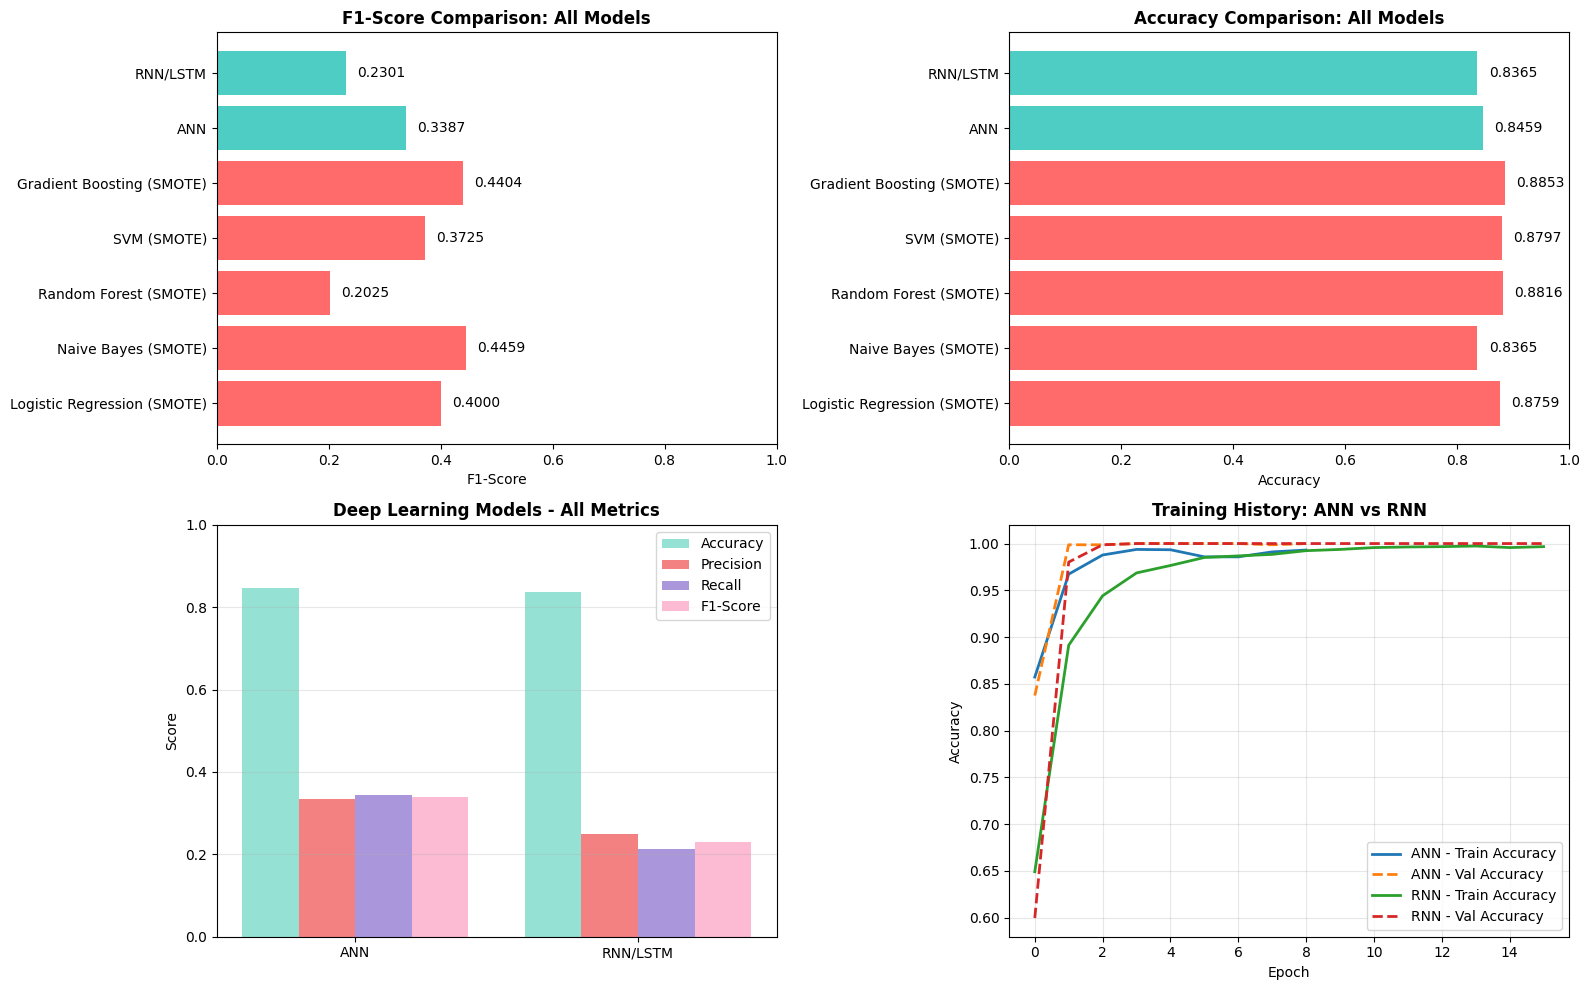


✅ COMPLETE ML PIPELINE WITH DEEP LEARNING FINISHED!


In [82]:
print("\n" + "="*60)
print("FINAL COMPARISON: ALL MODELS (ML + DEEP LEARNING)")
print("="*60)

# Compile all results
final_comparison = []

# Add SMOTE-based traditional ML models
for model_name in smote_models.keys():
    smote_pred = smote_models[model_name]
    final_comparison.append({
        'Model': f'{model_name} (SMOTE)',
        'Accuracy': round(accuracy_score(y_test_ml, smote_pred), 4),
        'Precision': round(precision_score(y_test_ml, smote_pred, average='binary'), 4),
        'Recall': round(recall_score(y_test_ml, smote_pred, average='binary'), 4),
        'F1-Score': round(f1_score(y_test_ml, smote_pred, average='binary'), 4),
        'Type': 'Traditional ML'
    })

# Add Deep Learning models
final_comparison.append({
    'Model': 'ANN',
    'Accuracy': round(ann_accuracy, 4),
    'Precision': round(ann_precision, 4),
    'Recall': round(ann_recall, 4),
    'F1-Score': round(ann_f1, 4),
    'Type': 'Deep Learning'
})

final_comparison.append({
    'Model': 'RNN/LSTM',
    'Accuracy': round(rnn_accuracy, 4),
    'Precision': round(rnn_precision, 4),
    'Recall': round(rnn_recall, 4),
    'F1-Score': round(rnn_f1, 4),
    'Type': 'Deep Learning'
})

final_df = pd.DataFrame(final_comparison)
print(final_df.to_string(index=False))

# Find best model overall
best_overall_idx = final_df['F1-Score'].idxmax()
best_overall = final_df.loc[best_overall_idx]

print(f"\n{'='*60}")
print(f"🏆 OVERALL BEST MODEL: {best_overall['Model']}")
print(f"   F1-Score: {best_overall['F1-Score']}, Accuracy: {best_overall['Accuracy']}")
print(f"{'='*60}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# All models F1-Score comparison
models_all = final_df['Model'].tolist()
f1_all = final_df['F1-Score'].tolist()
colors_all = ['#FF6B6B' if t == 'Traditional ML' else '#4ECDC4' for t in final_df['Type']]
axes[0, 0].barh(models_all, f1_all, color=colors_all)
axes[0, 0].set_xlabel('F1-Score')
axes[0, 0].set_title('F1-Score Comparison: All Models', fontweight='bold')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(f1_all):
    axes[0, 0].text(v + 0.02, i, f'{v:.4f}', va='center')

# Accuracy comparison
acc_all = final_df['Accuracy'].tolist()
axes[0, 1].barh(models_all, acc_all, color=colors_all)
axes[0, 1].set_xlabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison: All Models', fontweight='bold')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(acc_all):
    axes[0, 1].text(v + 0.02, i, f'{v:.4f}', va='center')

# Metrics for Deep Learning models
dl_models = ['ANN', 'RNN/LSTM']
dl_data = final_df[final_df['Type'] == 'Deep Learning'][['Accuracy', 'Precision', 'Recall', 'F1-Score']]
x = np.arange(len(dl_models))
width = 0.2
axes[1, 0].bar(x - 1.5*width, dl_data['Accuracy'].values, width, label='Accuracy', color='#95E1D3')
axes[1, 0].bar(x - 0.5*width, dl_data['Precision'].values, width, label='Precision', color='#F38181')
axes[1, 0].bar(x + 0.5*width, dl_data['Recall'].values, width, label='Recall', color='#AA96DA')
axes[1, 0].bar(x + 1.5*width, dl_data['F1-Score'].values, width, label='F1-Score', color='#FCBAD3')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Deep Learning Models - All Metrics', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(dl_models)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Training history for ANN vs RNN
axes[1, 1].plot(history_ann.history['accuracy'], label='ANN - Train Accuracy', linewidth=2)
axes[1, 1].plot(history_ann.history['val_accuracy'], label='ANN - Val Accuracy', linewidth=2, linestyle='--')
axes[1, 1].plot(history_rnn.history['accuracy'], label='RNN - Train Accuracy', linewidth=2)
axes[1, 1].plot(history_rnn.history['val_accuracy'], label='RNN - Val Accuracy', linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Training History: ANN vs RNN', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ COMPLETE ML PIPELINE WITH DEEP LEARNING FINISHED!")